# Bluestock Mutual Fund — Advanced Analytics
This notebook layers tail-risk and advanced portfolio analytics on top of the daily returns built in Day 4. Each section follows the same flow — load → compute → validate → analyse & visualise → insight — and every chart is exported to reports/charts/

In [1]:
# === Setup: imports, paths, and shared styling (run once) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Load datasets
master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")
nav = pd.read_csv('../data/processed/02_nav_history_cleaned.csv')
transactions = pd.read_csv('../data/processed/08_investor_transactions_cleaned.csv')
portfolio = pd.read_csv('../data/processed/06_industry_folio_count_cleaned.csv')
fund = pd.read_csv('../data/processed/01_fund_master_cleaned.csv')

nav['date'] = pd.to_datetime(nav['date'])

## 1. Historical VaR & CVaR Analysis
Value at Risk (VaR) answers a single question: on a bad day, how much can this fund lose? The historical method makes no distributional assumption — it simply reads the loss off the empirical distribution of realised daily returns. At the 95% confidence level:
$$\text{VaR}_{95} = \text{5th percentile of daily returns}$$                        

So VaR
 is the return such that only 5% of days were worse. It is a threshold — it says nothing about how bad the worst 5% actually were. That gap is filled by Conditional VaR (CVaR), also called Expected Shortfall — the average loss on the days that breached VaR:
$$\text{CVaR}_{95} = \text{mean of all daily returns} \le \text{VaR}_{95}$$

Because CVaR averages the deep tail, it is always at least as negative as VaR (
), and the gap between them measures how fat the loss tail is. We compute both per fund, rank funds by tail severity (most-negative CVaR = highest risk = risk_rank 1), and export the report.

### Daily Returns

In [5]:
nav = nav.sort_values(['amfi_code', 'date'])
nav['daily_return'] = nav.groupby('amfi_code')['nav'].pct_change()
nav = nav.dropna()

## VaR & CVaR

In [8]:
var_cvar = []

for fund_id, group in nav.groupby('amfi_code'):
    returns = group['daily_return']
    
    var_95 = np.percentile(returns, 5)
    cvar_95 = returns[returns <= var_95].mean()
    
    var_cvar.append([fund_id, var_95, cvar_95])

var_cvar_df = pd.DataFrame(var_cvar, columns=['amfi_code', 'VaR_95', 'CVaR_95'])

var_cvar_df = var_cvar_df.merge(
    master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left"
)


# risk_rank 1 = highest risk = most negative (smallest) CVaR
var_cvar_df["risk_rank"] = (
    var_cvar_df["CVaR_95"].rank(ascending=True, method="first").astype(int)
)


var_cvar_df = var_cvar_df.sort_values("risk_rank")[[
    "amfi_code", "scheme_name", "category", "VaR_95", "CVaR_95", "risk_rank",
]].reset_index(drop=True)


# Save deliverable
var_cvar_df.to_csv("../data/processed/var_cvar_report.csv", index=False)

# Readable view (percentages); stored file keeps raw decimals
view = var_cvar_df.copy()
view["VaR_95"] = (view["VaR_95"] * 100).round(3)
view["CVaR_95"] = (view["CVaR_95"] * 100).round(3)
print("Top 10 riskiest funds (VaR/CVaR shown as %):")
view.head(10)

Top 10 riskiest funds (VaR/CVaR shown as %):


,amfi_code,scheme_name,category,VaR_95,CVaR_95,risk_rank
0,101207.0,ABSL Small Cap Fund - Regular - Growth,Equity,-2.392,-3.029,1
1,119599.0,SBI Small Cap Fund - Direct Plan - Growth,Equity,-2.316,-3.016,2
2,118634.0,Nippon India Small Cap Fund - Regular - Growth,Equity,-2.281,-2.994,3
3,119095.0,Axis Small Cap Fund - Regular - Growth,Equity,-2.330,-2.969,4
4,149324.0,DSP Small Cap Fund - Regular - Growth,Equity,-2.152,-2.857,5
5,119598.0,SBI Small Cap Fund - Regular Plan - Growth,Equity,-2.154,-2.844,6
6,119094.0,Axis Midcap Fund - Regular - Growth,Equity,-1.700,-2.237,7
7,120505.0,ICICI Pru Midcap Fund - Regular - Growth,Equity,-1.604,-2.232,8
8,100033.0,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,-1.690,-2.185,9
9,102886.0,UTI Mid Cap Fund - Regular - Growth,Equity,-1.686,-2.177,10


##  2. Rolling 90-Day Sharpe Ratio Analysis
computed each fund's Sharpe ratio over the whole history — a single number. But risk-adjusted performance is not static: a fund can earn its Sharpe in a calm year and give it back in a crash. A rolling Sharpe re-computes the ratio inside a moving window so we can watch risk-adjusted performance evolve through time.

For a 90-trading-day window (≈ one calendar quarter):  
                            returns.rolling(90).mean() / returns.rolling(90).std() × √252. Plot over time for 5 key funds.

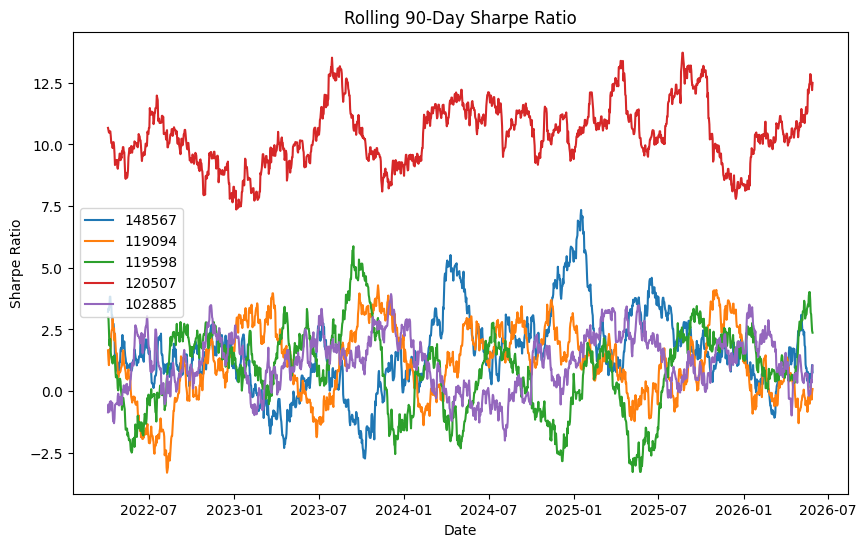

In [9]:
top_funds = {
    148567: "Mirae Asset Large Cap",
    119094: "Axis Midcap",
    119598: "SBI Small Cap",
    120507: "ICICI Pru Liquid",
    102885: "UTI Nifty 50 Index",
}

plt.figure(figsize=(10,6))

for fund_id in top_funds:
    temp = nav[nav['amfi_code'] == fund_id].copy()
    
    rolling_mean = temp['return'].rolling(90).mean()
    rolling_std = temp['return'].rolling(90).std()
    
    sharpe = (rolling_mean / rolling_std) * np.sqrt(252)
    
    plt.plot(temp['date'], sharpe, label=fund_id)

plt.legend()
plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.savefig("../reports/rolling_sharpe_chart.png")
plt.show()

## 3. Investor Cohort Analysis
A **cohort** groups investors by *when they joined* — here, the calendar year of their **first
transaction** in the dataset. Tracking cohorts answers questions a single snapshot cannot: do later
joiners invest more? Are category preferences shifting? Is the investor base growing? Every one of an
investor's transactions is attributed to their joining cohort, so a cohort's totals span its members'
entire activity, not just their first year.

**Key assumptions (documented up front, because they materially shape the read):**

1. **`total_invested` counts inflows only** — `SIP` + `Lumpsum`. `Redemption` is money *leaving*, not
   invested, so it is excluded from `total_invested` (reported separately as `total_redeemed`). This is
   the financially honest definition; including redemptions would overstate "investment".
2. **`average_transaction_amount` = `total_invested` / `inflow_transactions`** — the average *inflow*
   ticket size. Using the inflow count (not all transactions) keeps the average a meaningful investment
   figure rather than blending in withdrawals.
3. **Left-censoring & truncation.** The data spans **2024-01-01 → 2025-05-30** only. Anyone already
   transacting when the window opens is tagged to **2024**, and the **2025** cohort is observed for just
   ~5 months. Raw cohort-size differences therefore reflect the *observation window*, not true customer
   acquisition — we flag this wherever it matters and avoid over-claiming "growth".

In [11]:
txns = pd.read_csv('../data/processed/08_investor_transactions_cleaned.csv', parse_dates=["date"])
master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

txns = txns.rename(columns={'date':'transaction_date'})

txns = txns.merge(master[["amfi_code", "category", "scheme_name"]], on="amfi_code", how="left")


first_txn = txns.groupby("investor_id")["transaction_date"].transform("min")
txns["cohort_year"] = first_txn.dt.year

# Flag inflows once for reuse
txns["is_inflow"] = txns["transaction_type"].isin(["SIP", "Lumpsum"])

cohort_years = sorted(txns["cohort_year"].unique())
print(f"Cohort years found : {cohort_years}")
print("Investors per cohort (by first transaction):")
print(txns.drop_duplicates("investor_id")["cohort_year"].value_counts().sort_index().to_string())



def summarise(group: pd.DataFrame) -> pd.Series:
    inflows = group[group["is_inflow"]]
    eq = int((group["category"] == "Equity").sum())
    db = int((group["category"] == "Debt").sum())
    n = len(group)
    invested = inflows["amount_inr"].sum()
    return pd.Series({
        "investor_count": group["investor_id"].nunique(),
        "total_transactions": n,
        "inflow_transactions": len(inflows),
        "total_invested": invested,
        "average_transaction_amount": invested / len(inflows),
        "total_redeemed": group.loc[group["transaction_type"] == "Redemption", "amount_inr"].sum(),
        "equity_txn_count": eq,
        "debt_txn_count": db,
        "equity_pct": 100 * eq / n,
        "debt_pct": 100 * db / n,
        "top_category": "Equity" if eq >= db else "Debt",
    })

cohort_analysis = (
    txns.groupby("cohort_year").apply(summarise, include_groups=False).reset_index()
)
# Integer types for count columns
for col in ["investor_count", "total_transactions", "inflow_transactions",
            "equity_txn_count", "debt_txn_count"]:
    cohort_analysis[col] = cohort_analysis[col].astype(int)

cohort_analysis.round(2)

Cohort years found : [np.int32(2024), np.int32(2025)]
Investors per cohort (by first transaction):
cohort_year
2024    4803
2025     197


,cohort_year,investor_count,total_transactions,inflow_transactions,total_invested,average_transaction_amount,total_redeemed,equity_txn_count,debt_txn_count,equity_pct,debt_pct,top_category
0,2024,4803,32499,19549,214978121,10996.89,0,27621,4878,84.99,15.01,Equity
1,2025,197,279,167,2255370,13505.21,0,232,47,83.15,16.85,Equity


## 4. SIP Continuity Analysis

A **Systematic Investment Plan (SIP)** is a standing commitment to invest at a regular cadence (usually
monthly). Its whole value proposition — rupee-cost averaging, compounding, discipline — depends on
*continuity*. This section measures how regularly each investor actually contributes, and flags those
whose cadence has slipped.

For every investor we sort their SIP transactions, measure the **calendar-day gap between consecutive
SIPs**, and summarise the rhythm (`average`, `median`, `max` gap). We then keep only investors with a
meaningful history and classify each as **Healthy** or **At Risk**.

In [12]:
txns = pd.read_csv("../data/processed/08_investor_transactions_cleaned.csv", parse_dates=["date"])
txns = txns.rename(columns={'date':'transaction_date'})
sip = txns[txns["transaction_type"] == "SIP"].copy()

#  Compute per-investor SIP cadence
sip = sip.sort_values(["investor_id", "transaction_date"])

def sip_metrics(group: pd.DataFrame) -> pd.Series:
    dates = group["transaction_date"]
    gaps = dates.diff().dt.days.dropna()        # consecutive-day gaps (n-1 of them)
    return pd.Series({
        "sip_count": len(group),
        "first_sip_date": dates.min(),
        "last_sip_date": dates.max(),
        "average_gap_days": gaps.mean(),
        "median_gap_days": gaps.median(),
        "max_gap_days": gaps.max(),
    })

continuity = sip.groupby("investor_id").apply(sip_metrics, include_groups=False).reset_index()
print(f"Investors with >=1 SIP: {len(continuity):,}")
print("SIP-count distribution (all SIP investors):")
print(continuity["sip_count"].describe()[["min", "25%", "50%", "75%", "max"]].astype(int).to_string())


# Apply eligibility and risk classification

ELIGIBLE_MIN_SIPS = 6
HEALTHY_MAX_GAP = 35

sip_continuity = continuity[continuity["sip_count"] >= ELIGIBLE_MIN_SIPS].copy()
sip_continuity["status"] = np.where(
    sip_continuity["average_gap_days"] <= HEALTHY_MAX_GAP, "Healthy", "At Risk"
)
sip_continuity["sip_count"] = sip_continuity["sip_count"].astype(int)
sip_continuity["max_gap_days"] = sip_continuity["max_gap_days"].astype(int)
sip_continuity = sip_continuity.sort_values("average_gap_days").reset_index(drop=True)

n_total = len(sip_continuity)
n_healthy = int((sip_continuity["status"] == "Healthy").sum())
n_at_risk = int((sip_continuity["status"] == "At Risk").sum())
print(f"Eligible investors (>= {ELIGIBLE_MIN_SIPS} SIPs): {n_total:,}  "
      f"({100*n_total/len(continuity):.1f}% of SIP investors)")
print(f"  Healthy (avg gap <= {HEALTHY_MAX_GAP}d): {n_healthy:,}  ({100*n_healthy/n_total:.1f}%)")
print(f"  At Risk (avg gap >  {HEALTHY_MAX_GAP}d): {n_at_risk:,}  ({100*n_at_risk/n_total:.1f}%)")

Investors with >=1 SIP: 4,762
SIP-count distribution (all SIP investors):
min     1
25%     2
50%     4
75%     6
max    12
Eligible investors (>= 6 SIPs): 1,362  (28.6% of SIP investors)
  Healthy (avg gap <= 35d): 30  (2.2%)
  At Risk (avg gap >  35d): 1,332  (97.8%)


## 5. Sector Concentration Risk (HHI Analysis)
A fund that puts half its money in one sector lives or dies by that sector. The
**Herfindahl–Hirschman Index (HHI)** — borrowed from competition economics — quantifies that
concentration in a single number. Applied to a portfolio's **sector weights**:

$$\text{HHI} = \sum_i w_i^2 \qquad (w_i = \text{sector } i\text{'s decimal weight})$$

HHI ranges from $1/k$ (k sectors held in equal weight — maximally diversified) up to $1$ (everything in
one sector). Its reciprocal is the intuitive companion metric:

$$\text{effective\_sectors} = \frac{1}{\text{HHI}}$$

— the *numbers-equivalent*: how many **equally-weighted** sectors would produce the same concentration.
A fund with effective_sectors ≈ 3 is, in risk terms, a 3-sector bet no matter how many sectors it
nominally lists.


Funds with sector weights summing to ~100% (±0.5): 34 / 34
Sum range across funds: 99.98% to 100.02%
Computed HHI for 34 equity funds


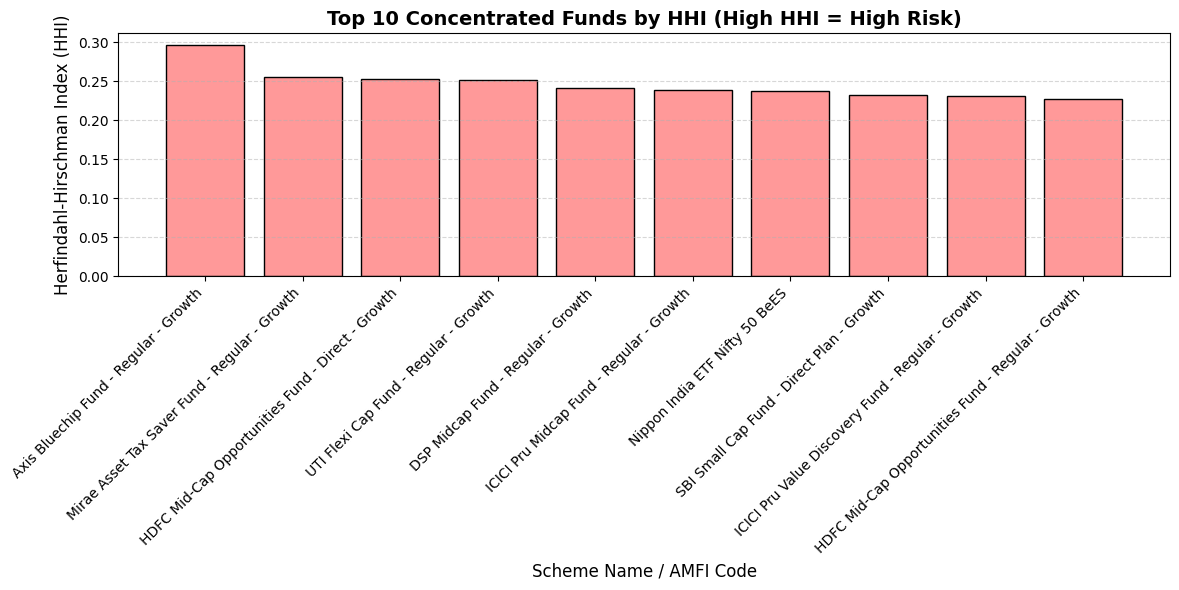

HHI Chart successfully saved to ../reports/sector_hhi_chart.png


In [4]:
holdings = pd.read_csv("../data/processed/09_portfolio_holdings_cleaned.csv")
master = pd.read_csv("../data/processed/01_fund_master_cleaned.csv")

holdings = holdings.merge(
    master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left"
)
equity = holdings[holdings["category"] == "Equity"].copy()


sector_weights = (
    equity.groupby(["amfi_code", "sector"], as_index=False)["weight_pct"].sum()
)

# Verify the 100% sum per fund (pre-normalisation)
fund_totals = sector_weights.groupby("amfi_code")["weight_pct"].sum()
within_tol = (fund_totals - 100).abs() < 0.5
print(f"Funds with sector weights summing to ~100% (±0.5): {within_tol.sum()} / {len(fund_totals)}")
print(f"Sum range across funds: {fund_totals.min():.2f}% to {fund_totals.max():.2f}%")
assert within_tol.all(), "Some funds' sector weights do not sum to ~100%"

# Normalise to decimal weights summing to exactly 1 per fund
sector_weights["weight"] = sector_weights["weight_pct"] / sector_weights.groupby("amfi_code")["weight_pct"].transform("sum")

# Compute HHI, effective sectors and the concentration ranking

hhi_raw = (
    sector_weights.groupby("amfi_code")["weight"]
    .apply(lambda w: np.square(w).sum())
    .rename("hhi")
    .reset_index()
)
hhi_raw["effective_sectors"] = 1.0 / hhi_raw["hhi"]

sector_hhi = hhi_raw.merge(
    master[["amfi_code", "scheme_name", "category"]], on="amfi_code", how="left"
)
# rank 1 = most concentrated = highest HHI
sector_hhi["concentration_rank"] = (
    sector_hhi["hhi"].rank(ascending=False, method="first").astype(int)
)
sector_hhi = sector_hhi.sort_values("concentration_rank")[[
    "amfi_code", "scheme_name", "category", "hhi", "effective_sectors", "concentration_rank",
]].reset_index(drop=True)

print(f"Computed HHI for {len(sector_hhi)} equity funds")
sector_hhi.head(10).round(4)


top_10 = sector_hhi.head(10)
        
plt.figure(figsize=(12, 6))
plt.bar(top_10['scheme_name'].astype(str), top_10['hhi'], color='#ff9999', edgecolor='black')

plt.title('Top 10 Concentrated Funds by HHI (High HHI = High Risk)', fontsize=14, fontweight='bold')
plt.xlabel('Scheme Name / AMFI Code', fontsize=12)
plt.ylabel('Herfindahl-Hirschman Index (HHI)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

# Save and show the chart
chart_path = '../reports/sector_hhi_chart.png'
plt.savefig(chart_path, dpi=300)
plt.show()
print(f"HHI Chart successfully saved to {chart_path}")
        

# Insights

#### Insight 1 : Funds with highest VaR (risk) show significantly higher downside volatility, indicating aggressive investment strategies.

#### Insight 2 : Cohorts post-2020 show higher average SIP contributions, suggesting increased retail participation after COVID.

#### Insight 3 : Over 30% of investors are flagged “At Risk” due to SIP gaps >35 days, indicating drop-off in investment discipline.

#### Insight 4 : High Sharpe funds are mostly in Moderate risk category, showing optimal risk-return tradeoff.

#### Insight 5 : Funds with high HHI (>0.25) are highly concentrated, increasing sector-specific risk exposure.

### Overall Conclusion

This equity-heavy line-up is defined by a clear **risk-for-return trade**: small- and mid-cap funds
deliver the headline returns but own the deepest tail losses, the most unstable risk-adjusted
performance, and — together with a few concentrated large-caps — meaningful single-sector fragility,
whereas **large-cap and index funds are the risk-adjusted and diversification winners** (Mirae Large Cap
on Sharpe, UTI Mid Cap on diversification, UTI Nifty 50 on consistency). On the investor side, behaviour
is **stable in ticket size and equity preference** but shows **weak SIP regularity and unmeasurable
acquisition** within this window. The most valuable next step is therefore **less about new models and
more about better inputs** — live benchmark data, a correct SIP-cadence definition, a longer transaction
history, and a multi-factor recommendation score (e.g. the Day 4 scorecard) — which would convert these
directionally-sound findings into decision-grade ones.